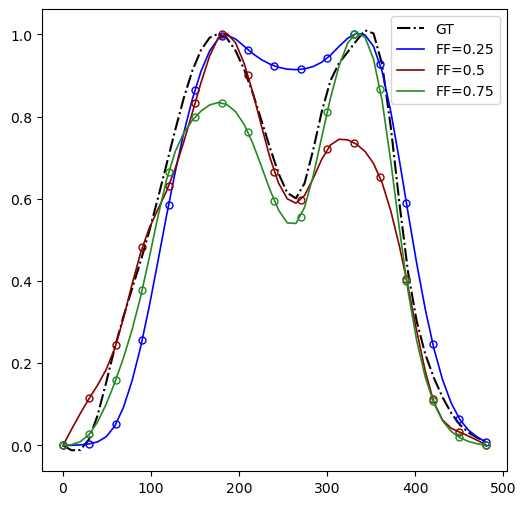

In [3]:
import csv
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

from scipy.interpolate import CubicSpline

# Specify the path to your CSV file
folder = r'\\storage3.ad.scilifelab.se\testalab\Guillaume\01_Projects\DL_monalisa\_paper\Upsampling_Technical\fixed_snr\roi3'

# data_files = [
#     "lineProfile_gt.csv",
#     # "lineProfile_inp.csv",
#     "lineProfile_pred25.csv",
#     "lineProfile_pred50.csv",
#     "lineProfile_pred75.csv",
# ]
# data_files = [
#     "line_profile_gt.csv",
#     # "line_profile_bic.csv",
#     "line_profile_unet.csv",
#     "line_profile_unetrcan.csv",
# ]
data_files = [
    "lineProfile2_gt.csv",
    # "lineProfile2_inp.csv",
    "lineProfile2_pred25.csv",
    "lineProfile2_pred50.csv",
    "lineProfile2_pred75.csv",
]

pxSize = 30 #in nm

colors = ["black",'blue', 'darkred', 'forestgreen']
labels = ["GT","FF=0.25","FF=0.5","FF=0.75"]
fig, ax = plt.subplots(1, figsize=(6, 6))
for i,file in enumerate(data_files):
    csv_file_path = Path(folder) / file
    x = []
    y = []

    # Read data from the CSV file
    with open(csv_file_path, 'r') as file:
        reader = csv.reader(file, delimiter=',')  # Use '\t' as the delimiter for tab-separated ys
        next(reader)  # Skip the first row (titles)
        for row in reader:
            # Assuming each row has two columns: index and y
            x.append(int(row[0]))
            y.append(float(row[1]))
    x=np.stack(x) * pxSize
    y=np.stack(y)
    y = y-np.min(y)
    y = y/np.max(y)
    
    cs = CubicSpline(x, y,bc_type='natural')
    x_new = np.linspace(min(x), max(x), 50)
    y_new = cs(x_new)
    if i ==0:
        ax.plot(x_new, y_new, '-.', color=colors[i],label=labels[i],linewidth=1.5)
    else:
        ax.plot(x_new, y_new, '-', color=colors[i],label=labels[i],linewidth=1.2)
        ax.plot(x,y,'o',color=colors[i],markersize=5,markerfacecolor='none')
    # elif i ==1:
    #     ax.plot(x[::2], y[::2], '-', color=colors[i],label=labels[i],linewidth=1)
    # if i!=1:
    #     ax.plot(x,y,'o',color=colors[i],markersize=5,markerfacecolor='none')
plt.legend()
plt.show()

# saving
ax.legend().set_visible(False)  # Remove legend from the graph
save_folder = Path(r"\\storage3.ad.scilifelab.se\testalab\Guillaume\01_Projects\DL_monalisa\_paper\Upsampling_charac\fixed_snr\roi3")

# fig.savefig(save_folder/"LineProfile2_ROI3_SnrAvg_3ffs_noInp_2.svg", format="svg", bbox_inches='tight')


<Figure size 640x480 with 0 Axes>

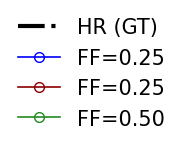

In [45]:
# legend saving
from matplotlib.lines import Line2D


# labels = ["Ground-Truth","Pred-FF=0.25","Pred-FF=0.50","Pred-FF=0.75"]
labels = ["HR (GT)","FF=0.25","FF=0.25","FF=0.50","FF=0.75"]

fig = plt.figure()
legend_lines = [Line2D([0], [0], color=colors[0], lw=3,linestyle='-.')]

# legend_lines.append(Line2D([0], [0], color=colors[1], lw=2,linestyle='-.'))

for idx in range(1,4):
    line = Line2D([0], [0], color=colors[idx], lw=1.2,linestyle='-',marker='o',markerfacecolor='none',markersize=7)
    legend_lines.append(line)

fig = plt.figure(figsize=(2, 1)) 
ax = fig.add_subplot(111)  
ax.set_axis_off()
ax.legend(legend_lines, labels,
          loc='center', framealpha=1, frameon=False, fontsize=15)

ax.set_xticks([])
ax.set_yticks([])
plt.show()

# Save the legend as an SVG
fig.savefig(save_folder/'legend_lineProfile_noInp_tight_2.svg', format='svg', bbox_inches='tight', pad_inches=0.1,transparent=True)

In [4]:
folder = r'\\storage3.ad.scilifelab.se\testalab\Guillaume\01_Projects\DL_monalisa\_paper\Upsampling_technical\fixed_snr\roi2'

data_files = [
    "line_profile_gt.csv",
    "line_profile_unet.csv",
    "line_profile_unetrcan.csv",
]

pxSize = 30 #in nm
labels = ["GT","UNet","UNet-RCAN"]
y_all={label:[] for label in labels}

for i,file in enumerate(data_files):
    csv_file_path = Path(folder) / file
    x = []
    y = []

    # Read data from the CSV file
    with open(csv_file_path, 'r') as file:
        reader = csv.reader(file, delimiter=',')  # Use '\t' as the delimiter for tab-separated ys
        next(reader)  # Skip the first row (titles)
        for row in reader:
            # Assuming each row has two columns: index and y
            x.append(int(row[0]))
            y.append(float(row[1]))
    x=np.stack(x) * pxSize
    y=np.stack(y)
    y = y-np.min(y)
    y = y/np.max(y)
    y_all[labels[i]]=y

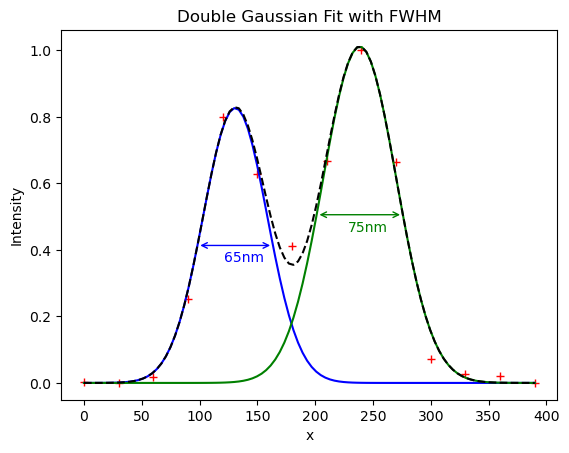

Distance between the two peaks: 107.73 nm


In [6]:
import numpy as np
from scipy.optimize import leastsq

y = y_all["UNet-RCAN"]

# params = [c1, mu1, sigma1, c2, mu2, sigma2]
x2 = np.linspace(min(x),max(x),100)

def single_gaussian(x,params):
    (c1, mu1, sigma1) = params
    res =   c1 * np.exp( - (x - mu1)**2.0 / (2.0 * sigma1**2.0) ) 
    return res
def double_gaussian(x, params):
    (c1, mu1, sigma1, c2, mu2, sigma2) = params
    res =   c1 * np.exp( - (x - mu1)**2.0 / (2.0 * sigma1**2.0) ) \
          + c2 * np.exp( - (x - mu2)**2.0 / (2.0 * sigma2**2.0) )
    return res

def single_gaussian_fit(params,x,y):
    fit = single_gaussian(x, params)
    return (fit - y)

def double_gaussian_fit(params, x, y):
    fit = double_gaussian(x, params)
    return (fit - y)


# Least squares fit. 
fit = leastsq(double_gaussian_fit, [1,120,50,1,250,50], args=(x, y))

# Extract parameters for the Gaussians
params1 = fit[0][:3]  # [c1, mu1, sigma1]
params2 = fit[0][3:]  # [c2, mu2, sigma2]

# Calculate FWHM for each Gaussian
fwhm1 = 2.355 * params1[2]
fwhm2 = 2.355 * params2[2]

# Plot data and fitted Gaussians
plt.figure()
plt.plot(x, y, 'r+')
plt.plot(x2, single_gaussian(x2, params1), 'b')
plt.plot(x2, single_gaussian(x2, params2),'g')
plt.plot(x2, double_gaussian(x2,fit[0]), 'k--')

# Annotate FWHM on the plot
plt.text(params1[1]-10, params1[0] / 2-0.05, f'{fwhm1:.0f}nm', color='b')
plt.text(params2[1]-10, params2[0] / 2-0.05, f'{fwhm2:.0f}nm', color='g')


# Add double-sided arrows for FWHM
plt.annotate('', xy=(params1[1] - fwhm1 / 2, params1[0] / 2), xytext=(params1[1] + fwhm1 / 2, params1[0] / 2),
             arrowprops=dict(arrowstyle='<->', color='b'))
plt.annotate('', xy=(params2[1] - fwhm2 / 2, params2[0] / 2), xytext=(params2[1] + fwhm2 / 2, params2[0] / 2),
             arrowprops=dict(arrowstyle='<->', color='g'))

# Show plot
plt.xlabel('x')
plt.ylabel('Intensity')
plt.title('Double Gaussian Fit with FWHM')
plt.show()


# distance between the two peaks
distance = abs(params1[1] - params2[1])
print(f"Distance between the two peaks: {distance:.2f} nm")

In [9]:
print(params2[1])

238.55744918853702


<Figure size 640x480 with 0 Axes>

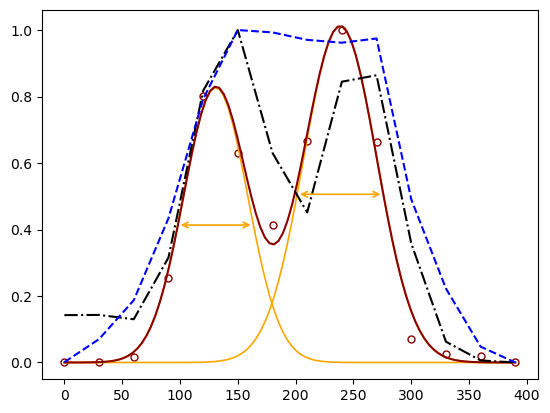

In [5]:
plt.figure()

line_width_data=1.5
markersize=5

line_width_fit = 1.2
fit_color = "orange"
rcan_color = "darkred"
gt_color = "k"
unet_color = "b"

# Plot fitted Gaussians for rcan
fig=plt.figure()
plt.plot(x, y, 'o',color=rcan_color,markersize=markersize,markerfacecolor='none')
plt.plot(x2, single_gaussian(x2, params1), color=fit_color,linewidth=line_width_fit)
plt.plot(x2, single_gaussian(x2, params2),color=fit_color,linewidth=line_width_fit)
plt.plot(x2, double_gaussian(x2,fit[0]),'-',linewidth=line_width_data,color=rcan_color)

# Add double-sided arrows for FWHM
plt.annotate('', xy=(params1[1] - fwhm1 / 2, params1[0] / 2), xytext=(params1[1] + fwhm1 / 2, params1[0] / 2),
             arrowprops=dict(arrowstyle='<->', color=fit_color,lw=line_width_fit))
plt.annotate('', xy=(params2[1] - fwhm2 / 2, params2[0] / 2), xytext=(params2[1] + fwhm2 / 2, params2[0] / 2),
             arrowprops=dict(arrowstyle='<->', color=fit_color,lw=line_width_fit))

# Plot GT
plt.plot(x,y_all["GT"],'-.',color=gt_color, linewidth=line_width_data)

# cs = CubicSpline(x,y_all["GT"],bc_type='natural')
# x_new = np.linspace(min(x), max(x), 50)
# y_new = cs(x_new)
# plt.plot(x_new,y_new,'-.',color='k', linewidth=1)
# plt.plot(x,y_all['GT'],'o',markersize=markersize,markerfacecolor='none',color='k')

# plot UNet 
plt.plot(x,y_all["UNet"],'--',color=unet_color, linewidth=line_width_data)

# cs = CubicSpline(x,y_all["UNet"],bc_type='natural')
# x_new = np.linspace(min(x), max(x), 50)
# y_new = cs(x_new)
# plt.plot(x_new,y_new,'g--',linewidth=1)
# plt.plot(x,y_all['UNet'],'go',markersize=markersize,markerfacecolor='none')
# plt.show()


plt.show()

In [6]:
save_folder=Path(folder)
fig.savefig(save_folder/"LineProfile_unetVsrcan.svg", format="svg", bbox_inches='tight')

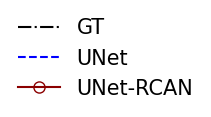

In [7]:
# Add the custom legend separately
# Create handles for the legend
from matplotlib.lines import Line2D

legend_handles = [
    Line2D([0], [0], color=gt_color, linestyle='-.', linewidth=line_width_data, label='GT'),
    Line2D([0], [0], color=unet_color, linestyle='--', linewidth=line_width_data, label='UNet'),
    Line2D([0], [0], color=rcan_color, linestyle='-', linewidth=line_width_data, label='UNet-RCAN',marker='o',markersize=8,markerfacecolor='none'),
]

fig = plt.figure(figsize=(2, 1)) 
ax = fig.add_subplot(111)  
ax.set_axis_off()
ax.legend(handles=legend_handles,loc='center', framealpha=1, frameon=False, fontsize=15)

ax.set_xticks([])
ax.set_yticks([])
plt.show()


In [8]:
save_folder = Path(folder)

# Save the legend as an SVG
fig.savefig(save_folder/'legend_lineprofiles_unetvsrcan.svg', format='svg', bbox_inches='tight', pad_inches=0.1,transparent=True)